In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [1]:
import sys
print(sys.executable)

c:\Users\devsr\anaconda3\python.exe


In [3]:
ds_sla = xr.open_dataset('SLA_UPDATED.nc')

In [4]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')

In [5]:
ocean_mask = ~ds_sla.sla.isel(time=0).isnull()

In [6]:
lat_idxs,lon_idxs = np.where(ocean_mask)

In [7]:
sla_now = ds_sla.sla

sla_lags = {
    f"sla_lag{i}": ds_sla.sla.shift(time=i)
    for i in range(1, 15)
}

target = ds_sla.sla.shift(time=-1)

In [8]:
ds_ml = xr.Dataset({
    "sla_now": sla_now,
    
    **sla_lags,
    

    "tmp_surface": ds_gfs.TMP_surface,
    "tmp_2m": ds_gfs.TMP_2maboveground,

    "ugrd": ds_gfs.UGRD_10maboveground,
    "vgrd": ds_gfs.VGRD_10maboveground,

    "dswrf": ds_gfs.DSWRF_surface,
    "uswrf": ds_gfs.USWRF_surface,
    "dlwrf": ds_gfs.DLWRF_surface,
    "ulwrf": ds_gfs.ULWRF_surface,

    "spfh": ds_gfs.SPFH_2maboveground,
    "prate": ds_gfs.PRATE_surface,

    "target": target
})

In [9]:
ds_ml["month"] = xr.DataArray(
    ds_ml.time.dt.month,
    dims=["time"]
)

ds_ml["dayofyear"] = xr.DataArray(
    ds_ml.time.dt.dayofyear,
    dims=["time"]
)

In [10]:
ds_ml = ds_ml.where(ocean_mask)

In [11]:
ds_ml = ds_ml.stack(point=("latitude", "longitude"))

In [54]:
ds_ml

<xarray.Dataset> Size: 6GB
Dimensions:      (time: 3930, point: 18560)
Coordinates:
  * time         (time) datetime64[ns] 31kB 2015-01-01 2015-01-02 ... 2025-10-05
  * point        (point) object 148kB MultiIndex
  * latitude     (point) float32 74kB 0.125 0.125 0.125 ... 28.88 28.88 28.88
  * longitude    (point) float32 74kB 50.12 50.38 50.62 ... 89.38 89.62 89.88
Data variables: (12/17)
    sla_now      (time, point) float32 292MB -0.0456 -0.0489 -0.0511 ... nan nan
    sla_lag1     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    sla_lag3     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    sla_lag7     (time, point) float32 292MB nan nan nan nan ... nan nan nan nan
    tmp_surface  (time, point) float32 292MB 300.9 300.9 300.9 ... nan nan nan
    tmp_2m       (time, point) float32 292MB 299.6 299.6 299.7 ... nan nan nan
    ...           ...
    ulwrf        (time, point) float32 292MB 465.5 465.5 465.5 ... nan nan nan
    spfh         (time, point) float32 292MB 0.01619 0.01618 0.01616 ... nan nan
    prate        (time, point) float32 292MB 1.719e-06 1.594e-06 ... nan nan
    target       (time, point) float32 292MB -0.0505 -0.0542 -0.0576 ... nan nan
    month        (time, point) float64 584MB 1.0 1.0 1.0 1.0 ... nan nan nan nan
    dayofyear    (time, point) float64 584MB 1.0 1.0 1.0 1.0 ... nan nan nan nan

In [12]:
df = ds_ml.to_dataframe().reset_index()

In [13]:
df = df.dropna()

In [14]:
df.shape

(49128429, 31)

In [15]:
print(df.memory_usage(deep=True).sum() / 1024**3)

6.588635757565498


In [16]:
import psutil

print("Total RAM:", psutil.virtual_memory().total / 1024**3, "GB")
print("Available:", psutil.virtual_memory().available / 1024**3, "GB")

Total RAM: 15.730339050292969 GB
Available: 6.533443450927734 GB


In [17]:
train = df[df.time < "2024-01-01"]
test  = df[df.time >= "2024-01-01"]

In [29]:
features = (
    ["sla_now"] 
    + [i for i in sla_lags] 
    + [
        "tmp_surface",
        "tmp_2m",

        "ugrd",
        "vgrd",

        "dswrf",
        "uswrf",
        "dlwrf",
        "ulwrf",

        "spfh",
        "prate",

        "month",
        "dayofyear",

        "latitude",
        "longitude"
        ])  

In [31]:
X_train = train[features]
y_train = train["target"]
X_test = test[features]
y_test = test["target"]

In [32]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [33]:
pred = model.predict(X_test)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)
print(f"Pred: {pred[-5:]}")
print(f"Y-test: {y_test.tail()}")
print("XGBoost RMSE:", rmse_xgb)

Pred: [0.13266854 0.15269049 0.14445686 0.13728505 0.13186747]
Y-test: 72921923    0.147000
72922080    0.159975
72922081    0.154400
72922082    0.148450
72922083    0.145950
Name: target, dtype: float32
XGBoost RMSE: 0.019740963626947605


In [34]:
pred_persistence = X_test["sla_now"]

In [35]:
rmse_persistence = np.sqrt(
    mean_squared_error(
        y_test,
        pred_persistence
    )
)

print("Persistence RMSE:", rmse_persistence)
print("XGBoost RMSE:", rmse_xgb)

Persistence RMSE: 0.018475373995563538
XGBoost RMSE: 0.019740963626947605


In [67]:
len(pred)

7929449

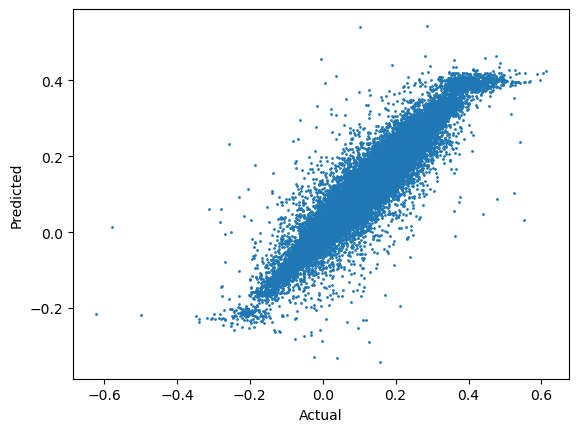

In [68]:
sample_idx = np.random.choice(len(pred), 100000, replace=False)

plt.scatter(
    y_test.values[sample_idx],
    pred[sample_idx],
    s=1
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
sample_idx

array([4657506, 1274276, 4312272, ...,  433852, 2857431, 4901645],
      shape=(100000,), dtype=int32)

In [36]:
fi = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(fi)

sla_now        0.813636
sla_lag1       0.167983
sla_lag2       0.005273
sla_lag3       0.003621
sla_lag5       0.001236
sla_lag4       0.001008
sla_lag8       0.000538
month          0.000504
sla_lag9       0.000453
latitude       0.000434
sla_lag11      0.000389
longitude      0.000367
sla_lag14      0.000361
dayofyear      0.000346
sla_lag7       0.000342
sla_lag12      0.000328
sla_lag13      0.000311
ulwrf          0.000303
sla_lag10      0.000302
dlwrf          0.000300
spfh           0.000294
sla_lag6       0.000291
dswrf          0.000218
uswrf          0.000216
tmp_surface    0.000204
ugrd           0.000197
tmp_2m         0.000188
vgrd           0.000183
prate          0.000175
dtype: float32


In [71]:
pred.shape

(7929449,)

In [72]:
y_test.shape

(7929449,)

In [37]:
(pred-y_test.values)

array([ 0.01128472,  0.01212969,  0.01412849, ..., -0.00994314,
       -0.01116493, -0.01408252], shape=(7938471,), dtype=float32)

In [41]:
pred.shape

(7938471,)

In [42]:
X_test.columns

Index(['sla_now', 'sla_lag1', 'sla_lag2', 'sla_lag3', 'sla_lag4', 'sla_lag5',
       'sla_lag6', 'sla_lag7', 'sla_lag8', 'sla_lag9', 'sla_lag10',
       'sla_lag11', 'sla_lag12', 'sla_lag13', 'sla_lag14', 'tmp_surface',
       'tmp_2m', 'ugrd', 'vgrd', 'dswrf', 'uswrf', 'dlwrf', 'ulwrf', 'spfh',
       'prate', 'month', 'dayofyear', 'latitude', 'longitude'],
      dtype='str')

In [43]:
error_df = X_test[['latitude', 'longitude']].copy()

error_df['error'] = pred - y_test.values

In [52]:
error_map = error_df.pivot_table(
    index='latitude',
    columns='longitude',
    values='error'
)

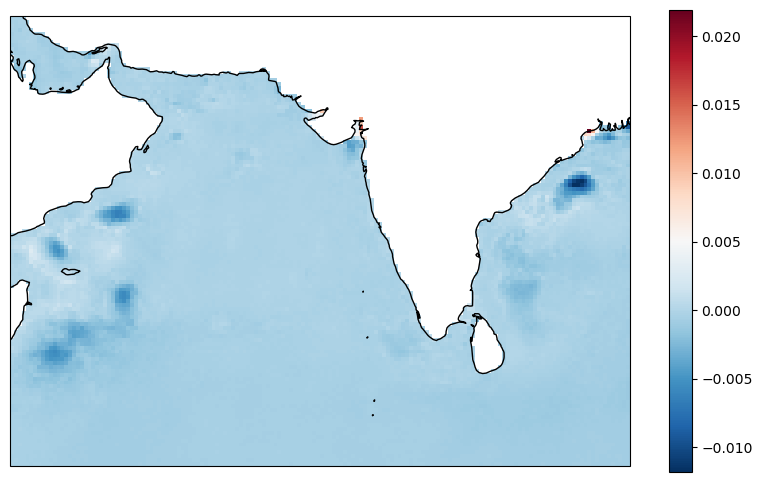

In [53]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    error_map.columns,
    error_map.index,
    error_map.values,
    cmap="RdBu_r",
    transform=ccrs.PlateCarree()
)

ax.coastlines()
plt.colorbar(pcm)

In [75]:
type(pred),type(y_test)

(numpy.ndarray, pandas.Series)

In [76]:
print(y_test.index)

Index([60988160, 60988161, 60988162, 60988163, 60988164, 60988165, 60988166,
       60988167, 60988168, 60988169,
       ...
       72903203, 72903204, 72903360, 72903361, 72903362, 72903363, 72903520,
       72903521, 72903522, 72903523],
      dtype='int64', length=7929449)
